# **Proyek Profiling dan Segmentasi UMKM**

## 1. Data Understanding & Business Questions

UMKM merupakan tulang punggung perekonomian, namun menunjukkan variasi performa yang signifikan antar pelaku usaha. Untuk mendukung perumusan kebijakan dan program pengembangan yang lebih tepat sasaran, maka diperlukan pemahaman berbasis data mengenai karakteristik UMKM, faktor yang berkaitan dengan performa usaha, serta peran legalitas bisnis.

Analisis ini menggunakan dataset UMKM untuk menghasilkan insight yang relevan bagi pemangku kepentingan, seperti pemerintah, pendamping UMKM, dan pemilik usaha. Fokus analisis diarahkan pada tiga business question utama berikut:
- **Bagaimana profil umum UMKM dalam dataset ini?**

    Memberikan gambaran dasar sebagai konteks awal analisis.

- **Faktor apa saja yang berkaitan dengan tingkat omset UMKM?**

    Mengidentifikasi karakteristik yang cenderung dimiliki UMKM dengan performa omset lebih tinggi.

- **Apakah legalitas usaha berkaitan dengan performa UMKM (omset dan laba)?**

    Mengevaluasi hubungan antara formalitas usaha dan kinerja bisnis.


## 2. Data Overview

In [50]:
# Import neccesary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)
sns.set(style="whitegrid")

In [51]:
# "../data/
df = pd.read_csv("../data/dataset-umkm-modified.csv")
df["aset"] = df["aset"].round().astype("int")
df.head()

,id_umkm,nama_usaha,jenis_usaha,tenaga_kerja_perempuan,tenaga_kerja_laki_laki,aset,omset,marketplace,kapasitas_produksi,status_legalitas,tahun_berdiri,laba,biaya_karyawan,jumlah_pelanggan
0,28828567,UD. Alif Pamungkas,Makanan & Minuman,2,2,6079294,9493293,Tokopedia,729,Belum Terdaftar,2015,1015874,171000000,479
1,28828568,UD. Zidanar Panji,Fashion,4,3,8691723,9783071,Bukalapak,411,Terdaftar,2014,2275862,147000000,464
2,28828569,UD. Winda Jayengprana,Makanan & Minuman,1,2,8114531,8572021,Website Sendiri,802,Belum Terdaftar,2000,2930434,375000000,383
3,28828570,UD. Damaris Satria,Perusahaan,2,2,2143881,7898700,Website Sendiri,1333,Belum Terdaftar,2003,456303,282000000,986
4,28828571,UD. Qasya Wiratama,Fashion,0,1,8535507,9148899,Lazada,263,Belum Terdaftar,2002,1686161,450000000,314


In [52]:
df.shape  # (jumlah_baris, jumlah_kolom)

(13564, 14)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13564 entries, 0 to 13563
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id_umkm                 13467 non-null  str  
 1   nama_usaha              13564 non-null  str  
 2   jenis_usaha             13564 non-null  str  
 3   tenaga_kerja_perempuan  13564 non-null  int64
 4   tenaga_kerja_laki_laki  13564 non-null  int64
 5   aset                    13564 non-null  int64
 6   omset                   13564 non-null  int64
 7   marketplace             13447 non-null  str  
 8   kapasitas_produksi      13564 non-null  int64
 9   status_legalitas        13564 non-null  str  
 10  tahun_berdiri           13469 non-null  str  
 11  laba                    13564 non-null  int64
 12  biaya_karyawan          13469 non-null  str  
 13  jumlah_pelanggan        13453 non-null  str  
dtypes: int64(6), str(8)
memory usage: 1.4 MB


## 3. Data Preparation

In [54]:
numeric_cols = [
    "aset",
    "omset",
    "laba",
    "biaya_karyawan",
    "kapasitas_produksi",
    "jumlah_pelanggan",
    "tenaga_kerja_perempuan",
    "tenaga_kerja_laki_laki",
    "tahun_berdiri"
]

In [55]:
def clean_numeric(series):
    return (
        series
        .astype(str)
        .str.replace(r"[^\d]", "", regex=True)
        .replace("", np.nan)
        .astype(float)
    )

In [56]:
for col in numeric_cols:
    df[col] = clean_numeric(df[col])

In [57]:
df[numeric_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 13564 entries, 0 to 13563
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   aset                    13564 non-null  float64
 1   omset                   13564 non-null  float64
 2   laba                    13564 non-null  float64
 3   biaya_karyawan          13430 non-null  float64
 4   kapasitas_produksi      13564 non-null  float64
 5   jumlah_pelanggan        13412 non-null  float64
 6   tenaga_kerja_perempuan  13564 non-null  float64
 7   tenaga_kerja_laki_laki  13564 non-null  float64
 8   tahun_berdiri           13436 non-null  float64
dtypes: float64(9)
memory usage: 953.8 KB


In [58]:
categorical_cols = [
    "jenis_usaha",
    "marketplace",
    "status_legalitas"
]

for col in categorical_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )

In [59]:
missing_summary = pd.DataFrame({
    "Kolom": numeric_cols,
    "Persentase Missing (%)": df[numeric_cols].isna().mean().values * 100,
    "Jumlah Missing": df[numeric_cols].isna().sum().values
})

missing_summary.round(2)

,Kolom,Persentase Missing (%),Jumlah Missing
0,aset,0.00,0
1,omset,0.00,0
2,laba,0.00,0
3,biaya_karyawan,0.99,134
4,kapasitas_produksi,0.00,0
5,jumlah_pelanggan,1.12,152
6,tenaga_kerja_perempuan,0.00,0
7,tenaga_kerja_laki_laki,0.00,0
8,tahun_berdiri,0.94,128


In [60]:
df["missing_key_flag"] = df[numeric_cols].isna().any(axis=1)

df_complete = df[df["missing_key_flag"] == False]
df_incomplete = df[df["missing_key_flag"] == True]

df_complete.shape, df_incomplete.shape

((13151, 15), (413, 15))

In [61]:
duplicate_rows = df[df.duplicated(subset="nama_usaha", keep=False)]
duplicate_rows.shape

(0, 15)

In [62]:
df_clean = df.drop_duplicates(subset="nama_usaha", keep="first")

In [63]:
def detect_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

for col in ["aset", "omset", "laba"]:
    df[f"outlier_{col}"] = detect_outlier(df[col])

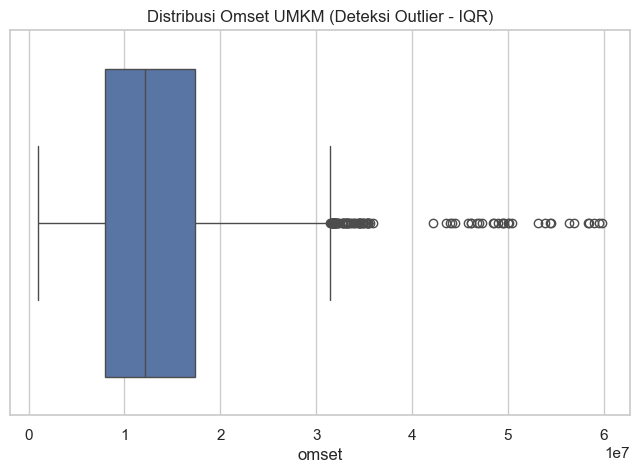

In [64]:
sns.boxplot(x=df["omset"])
plt.title("Distribusi Omset UMKM (Deteksi Outlier - IQR)")
plt.show()

In [65]:
df_complete.info()

<class 'pandas.DataFrame'>
Index: 13151 entries, 0 to 13563
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_umkm                 13055 non-null  str    
 1   nama_usaha              13151 non-null  str    
 2   jenis_usaha             13151 non-null  str    
 3   tenaga_kerja_perempuan  13151 non-null  float64
 4   tenaga_kerja_laki_laki  13151 non-null  float64
 5   aset                    13151 non-null  float64
 6   omset                   13151 non-null  float64
 7   marketplace             13035 non-null  str    
 8   kapasitas_produksi      13151 non-null  float64
 9   status_legalitas        13151 non-null  str    
 10  tahun_berdiri           13151 non-null  float64
 11  laba                    13151 non-null  float64
 12  biaya_karyawan          13151 non-null  float64
 13  jumlah_pelanggan        13151 non-null  float64
 14  missing_key_flag        13151 non-null  bool   
dtypes

## 4. Exploratory Data Analysis

### **BQ1 - Profil Umum UMKM**

In [66]:
bq1_cols = [
    "nama_usaha",
    "jenis_usaha",
    "status_legalitas",
    "tahun_berdiri"
]

df_bq1 = df[bq1_cols].copy()

In [67]:
df_bq1.isna().sum()

nama_usaha            0
jenis_usaha           0
status_legalitas      0
tahun_berdiri       128
dtype: int64

In [68]:
jenis_usaha_dist = (
    df_bq1["jenis_usaha"]
    .value_counts(dropna=False)
    .to_frame(name="jumlah_umkm")
)

jenis_usaha_dist

,jumlah_umkm
jenis_usaha,
Makanan & Minuman,3132
Perdagangan,2487
Jasa,2302
Fashion,1732
Perusahaan,1702
Pendidikan,1571
Kesehatan,638


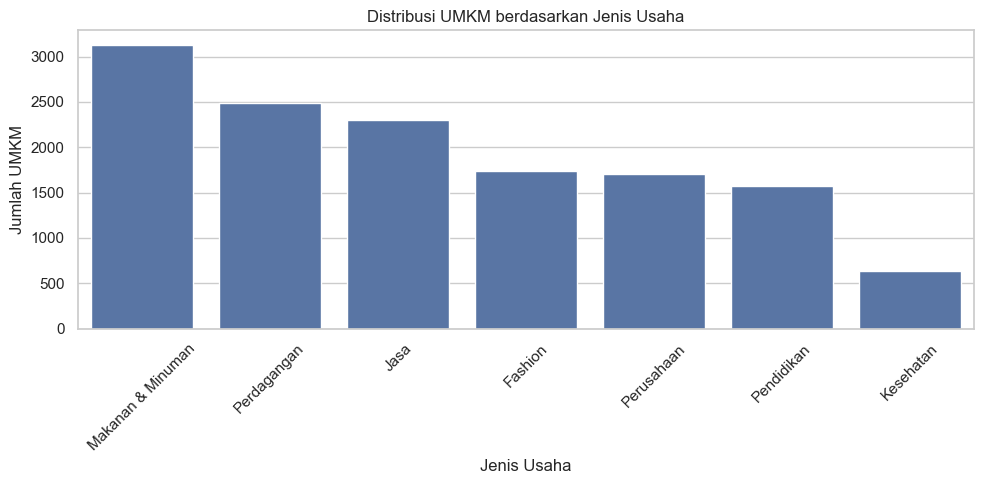

In [69]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=jenis_usaha_dist.index,
    y=jenis_usaha_dist["jumlah_umkm"]
)

plt.title("Distribusi UMKM berdasarkan Jenis Usaha")
plt.xlabel("Jenis Usaha")
plt.ylabel("Jumlah UMKM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
status_legalitas_dist = (
    df_bq1["status_legalitas"]
    .value_counts(dropna=False)
    .to_frame(name="jumlah_umkm")
)

status_legalitas_dist

,jumlah_umkm
status_legalitas,
Belum Terdaftar,7521
Terdaftar,6043


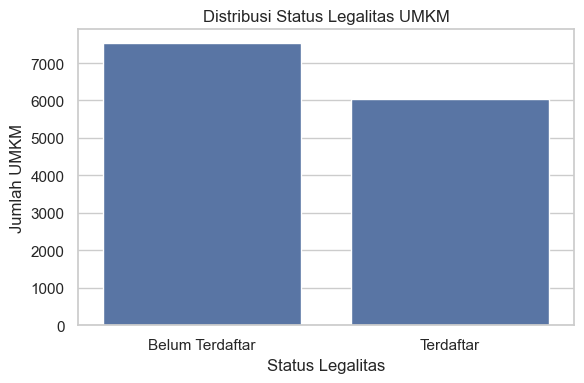

In [71]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=status_legalitas_dist.index,
    y=status_legalitas_dist["jumlah_umkm"]
)

plt.title("Distribusi Status Legalitas UMKM")
plt.xlabel("Status Legalitas")
plt.ylabel("Jumlah UMKM")
plt.tight_layout()
plt.show()

In [72]:
df_bq1["tahun_berdiri"] = pd.to_numeric(
    df_bq1["tahun_berdiri"], errors="coerce"
).astype("Int64")

In [73]:
umkm_per_tahun = (
    df_bq1
    .dropna(subset=["tahun_berdiri"])
    .groupby("tahun_berdiri")
    .size()
    .reset_index(name="jumlah_umkm")
    .sort_values("tahun_berdiri")
)

umkm_per_tahun.head()

,tahun_berdiri,jumlah_umkm
0,2000,535
1,2001,531
2,2002,508
3,2003,533
4,2004,534


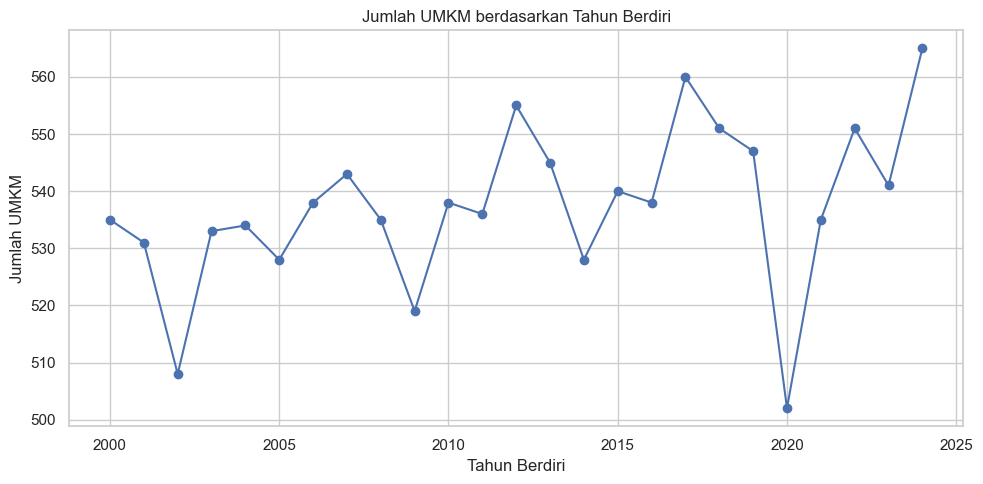

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(
    umkm_per_tahun["tahun_berdiri"],
    umkm_per_tahun["jumlah_umkm"],
    marker="o"
)

plt.title("Jumlah UMKM berdasarkan Tahun Berdiri")
plt.xlabel("Tahun Berdiri")
plt.ylabel("Jumlah UMKM")
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight Awal – Profil UMKM (WIP)
Berdasarkan distribusi sektor, legalitas, dan tahun berdiri, profil umum UMKM dalam dataset ini dapat digambarkan sebagai berikut:
- Mayoritas UMKM dalam dataset bergerak di sektor Makanan & Minuman, menunjukkan bahwa bisnis berbasis konsumsi harian memiliki daya tarik dan barrier to entry yang relatif rendah. Sedangkan sektor Kesehatan memiliki jumlah UMKM paling rendah, kemungkinan karena memerlkan regulasi dan modal awal yang lebih tinggi.
- Distribusi sektor cukup beragam, sehingga dataset mencerminkan struktur UMKM yang heterogen dan tidak terfokus pada satu industri saja.
- Proporsi UMKM yang belum memiliki legalitas usaha masih berat di bagian Belum Terdaftar (non-legal), yang menunjukkan bahwa tingkat formalitas UMKM masih belum sepenuhnya optimal. Namun tingkat legalitas masih relatif seimbang antara terdaftar dan belum terdaftar.
- Pertumbuhan UMKM cenderung stabil dari tahun ke tahun dengan sedikit fluktuasi dan penurunan yang cukup signifikan pada 2020, yang bisa diasosiasikan dengan faktor eksternal pandemi.

### **BQ2 - Faktor yang Berkaitan dengan Omset**

In [75]:
bq2_cols = [
    "omset",
    "aset",
    "tenaga_kerja_laki_laki",
    "tenaga_kerja_perempuan",
    "kapasitas_produksi"
]

df_bq2 = df_complete[bq2_cols].copy()

In [76]:
'''
current_year = df_bq2["tahun_berdiri"].max()
df_bq2["lama_usaha"] = current_year - df_bq2["tahun_berdiri"]
'''

'\ncurrent_year = df_bq2["tahun_berdiri"].max()\ndf_bq2["lama_usaha"] = current_year - df_bq2["tahun_berdiri"]\n'

In [77]:
df_bq2["omset"].describe()

count    1.315100e+04
mean     1.328324e+07
std      7.014361e+06
min      1.000509e+06
25%      8.018974e+06
50%      1.215831e+07
75%      1.743250e+07
max      5.980217e+07
Name: omset, dtype: float64

In [78]:
q1 = df_bq2["omset"].quantile(0.25)
q3 = df_bq2["omset"].quantile(0.75)
iqr = q3 - q1

q1, q3, iqr

(np.float64(8018974.5), np.float64(17432501.5), np.float64(9413527.0))

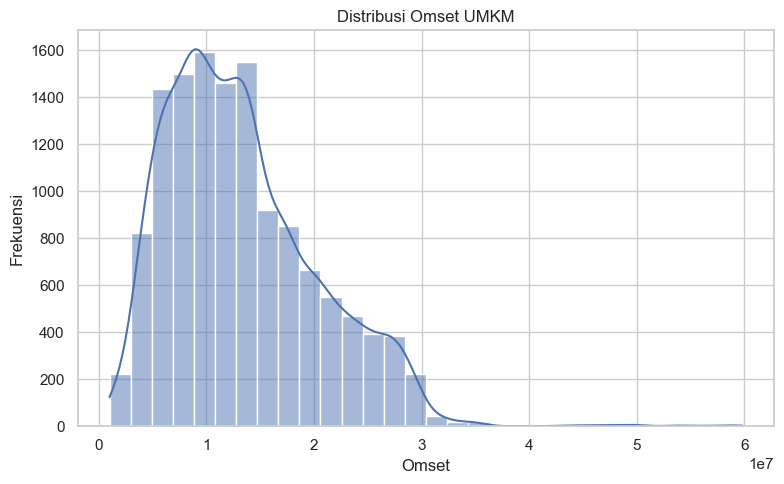

In [79]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_bq2["omset"],
    bins=30,
    kde=True
)

plt.title("Distribusi Omset UMKM")
plt.xlabel("Omset")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

In [80]:
df_bq2[["aset", "omset"]].corr(method="pearson")

,aset,omset
aset,1.000000,0.722194
omset,0.722194,1.000000


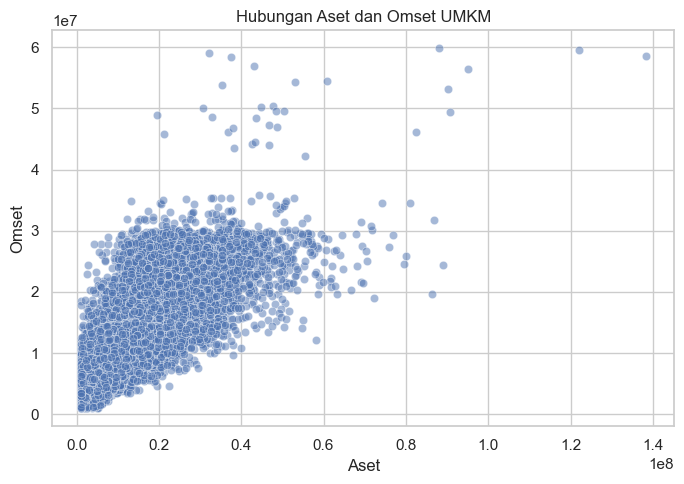

In [82]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="aset",
    y="omset",
    data=df_bq2,
    alpha=0.5
)

plt.title("Hubungan Aset dan Omset UMKM")
plt.xlabel("Aset")
plt.ylabel("Omset")
plt.tight_layout()
plt.show()

In [83]:
df_bq2["total_tenaga_kerja"] = (
    df_bq2["tenaga_kerja_laki_laki"] +
    df_bq2["tenaga_kerja_perempuan"]
)

In [84]:
df_bq2[["total_tenaga_kerja", "omset"]].corr()

,total_tenaga_kerja,omset
total_tenaga_kerja,1.00000,0.76411
omset,0.76411,1.00000


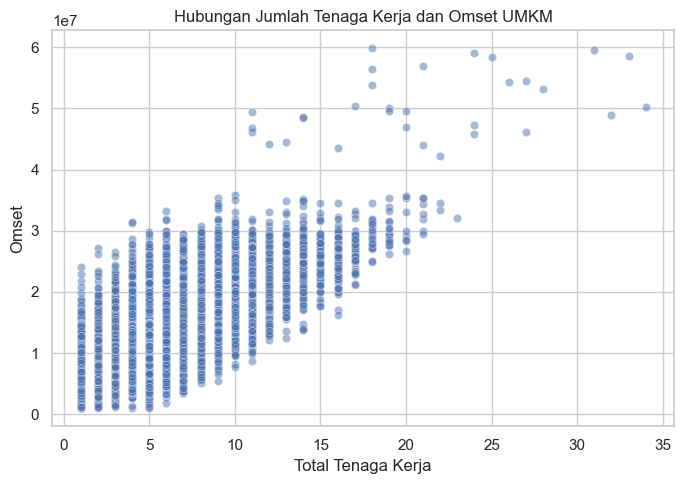

In [85]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="total_tenaga_kerja",
    y="omset",
    data=df_bq2,
    alpha=0.5
)

plt.title("Hubungan Jumlah Tenaga Kerja dan Omset UMKM")
plt.xlabel("Total Tenaga Kerja")
plt.ylabel("Omset")
plt.tight_layout()
plt.show()

In [86]:
df_bq2[["kapasitas_produksi", "omset"]].corr()

,kapasitas_produksi,omset
kapasitas_produksi,1.000000,0.568931
omset,0.568931,1.000000


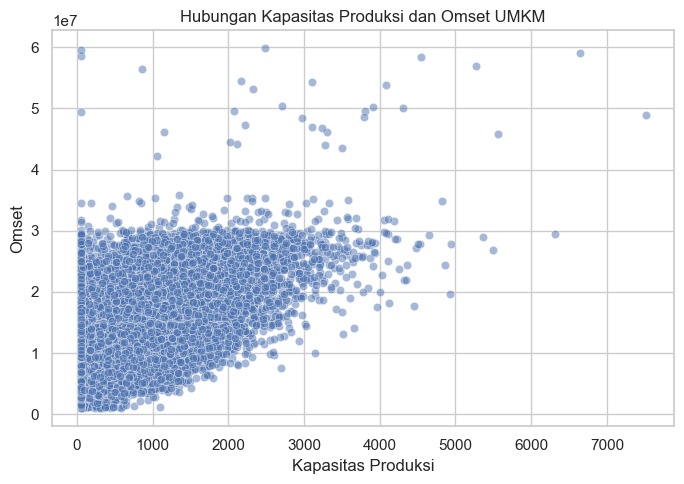

In [87]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="kapasitas_produksi",
    y="omset",
    data=df_bq2,
    alpha=0.5
)

plt.title("Hubungan Kapasitas Produksi dan Omset UMKM")
plt.xlabel("Kapasitas Produksi")
plt.ylabel("Omset")
plt.tight_layout()
plt.show()

### Insight Awal – Faktor yang Berkaitan dengan Omset (WIP)
- Distribusi omset UMKM cenderung right-skewed, yang berarti sebagian besar UMKM memiliki omset pada rentang rendah–menengah, sementara hanya sebagian kecil yang memiliki omset sangat tinggi.
- Aset menunjukkan hubungan positif dengan omset, meskipun sebaran cukup lebar. Aset merupakan salah satu faktor yang paling berkaitan dengan omset. Hal ini masuk akal secara ekonomi karena aset mencerminkan kapasitas modal, serta memungkinkan peningkatan produksi, distribusi, dan skala usaha itu sendiri.
- Jumlah tenaga kerja berkorelasi positif dengan omset, UMKM dengan tenaga kerja lebih banyak cenderung memiliki omset lebih tinggi. Namun, efisiensi dan produktivitas per pekerja juga berperan penting.
- Kapasitas produksi berkorelasi positif moderat, terdapat kecenderungan bahwa semakin tinggi kapasitas produksi maka semakin tinggi juga omset. Tetapi, pengaruhnya tidak sekuat aset. Kapasitas mencerminkan potensi produksi, namun omset dipengaruhi juga oleh permintaan dan manajemen usaha.

### **BQ3 - Peran Legalitas terhadap Performa UMKM**

In [88]:
bq3_cols = [
    "status_legalitas",
    "omset",
    "laba"
]

df_bq3 = df_complete[bq3_cols].copy()

In [89]:
df_bq3 = df_bq3[
    df_bq3["status_legalitas"].isin(["Terdaftar", "Belum Terdaftar"])
]

In [90]:
median_performance = (
    df_bq3
    .groupby("status_legalitas")[["omset", "laba"]]
    .median()
)

median_performance

,omset,laba
status_legalitas,,
Belum Terdaftar,11281935.0,2302104.5
Terdaftar,13310749.0,3695892.0


C:\Users\User\AppData\Local\Temp\ipykernel_22604\3749076470.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


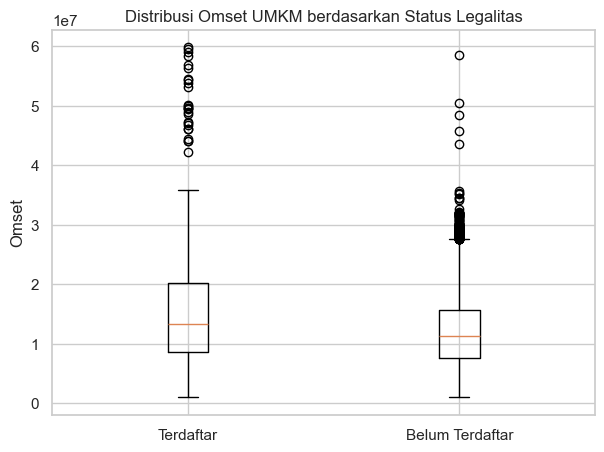

In [91]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [df_bq3[df_bq3["status_legalitas"] == "Terdaftar"]["omset"],
     df_bq3[df_bq3["status_legalitas"] == "Belum Terdaftar"]["omset"]],
    labels=["Terdaftar", "Belum Terdaftar"],
    showfliers=True
)

plt.ylabel("Omset")
plt.title("Distribusi Omset UMKM berdasarkan Status Legalitas")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22604\1818917269.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


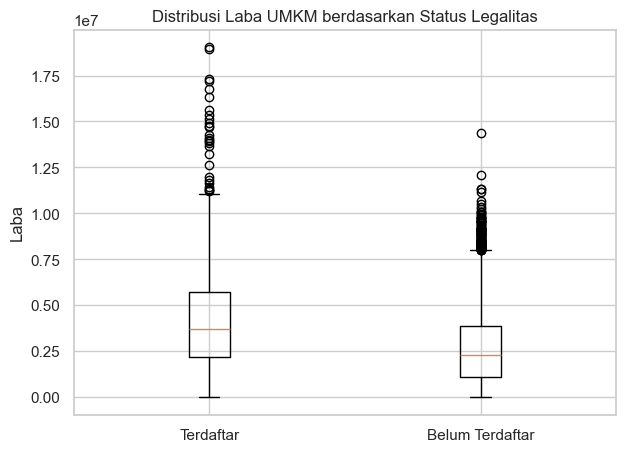

In [92]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [df_bq3[df_bq3["status_legalitas"] == "Terdaftar"]["laba"],
     df_bq3[df_bq3["status_legalitas"] == "Belum Terdaftar"]["laba"]],
    labels=["Terdaftar", "Belum Terdaftar"],
    showfliers=True
)

plt.ylabel("Laba")
plt.title("Distribusi Laba UMKM berdasarkan Status Legalitas")
plt.show()

### Insight Awal – Legalitas dan Performa UMKM (WIP)
- UMKM dengan status legalitas terdaftar memiliki median omset yang lebih tinggi dibandingkan UMKM yang belum terdaftar. Banyak titik ekstrem (omset sangat tinggi) berada pada kelompok terdaftar, menunjukkan bahwa UMKM skala besar cenderung sudah memiliki legalitas.
- Pola serupa terlihat pada median laba, namun selisih laba relatif lebih besar secara proporsional dibanding selisih omset. Ini menunjukkan bahwa UMKM legal memiliki peluang menghasilkan laba jauh lebih tinggi, meskipun risikonya juga lebih variatif.
- Meskipun demikian, terdapat tumpang tindih distribusi yang cukup besar, menunjukkan bahwa legalitas bukan satu-satunya faktor yang memengaruhi performa UMKM.
> **Catatan:** Analisis ini bersifat deskriptif dan menunjukkan asosiasi antara status legalitas dan performa UMKM. Hasil ini tidak dapat diinterpretasikan sebagai hubungan sebab-akibat.

## 5. Key Insights Summary

Berdasarkan hasil analisis eksploratif terhadap dataset, profil umum UMKM menunjukkan dominasi sektor konsumsi seperti Makanan & Minuman, dengan mayoritas usaha berada pada skala kecil hingga menengah. Distribusi omset bersifat positively skewed, di mana sebagian besar UMKM memiliki omset pada rentang rendah–menengah dan hanya sebagian kecil yang mencapai omset sangat tinggi.

Analisis hubungan antarvariabel menunjukkan bahwa tenaga kerja merupakan faktor yang paling konsisten berkaitan dengan omset. Ini menunjukkan bahwa skala operasional berbasis sumber daya manusia menjadi faktor yang lebih berkaitan dengan peningkatan pendapatan usaha. Temuan ini mencerminkan karakteristik UMKM yang cenderung padat karya, di mana peningkatan jumlah pekerja secara langsung berkaitan dengan peningkatan kapasitas produksi dan volume penjualan. Aset dan kapasitas produksi juga menunjukkan hubungan positif dengan omset, meskipun variasi performa yang cukup besar pada tingkat skala yang sama mengindikasikan bahwa faktor lain seperti efisiensi operasional, strategi pemasaran, dan kualitas manajemen turut memengaruhi kinerja usaha. 

Selain itu, UMKM dengan status legalitas usaha cenderung memiliki median omset dan laba yang lebih tinggi dibandingkan yang belum terdaftar, yang dapat mengisyaratkan bahwa formalitas usaha berpotensi berkaitan dengan peningkatan performa bisnis. Meskipun demikian, terdapat tumpang tindih distribusi yang cukup besar, menunjukkan bahwa legalitas bukan satu-satunya faktor yang memengaruhi performa UMKM.

## 6. Segmentasi UMKM (Rule-Based)

In [93]:
median_omset = df["omset"].median()
median_omset

np.float64(12139110.5)

In [94]:
df["kategori_omset"] = np.where(
    df["omset"] > median_omset,
    "High",
    "Low"
)

In [95]:
def assign_segment(row):
    if row["kategori_omset"] == "High" and row["status_legalitas"] == "Terdaftar":
        return "Segmen 1 – High Performing & Legal"
    
    elif row["kategori_omset"] == "High" and row["status_legalitas"] == "Belum Terdaftar":
        return "Segmen 2 – Growing but Informal"
    
    elif row["kategori_omset"] == "Low" and row["status_legalitas"] == "Terdaftar":
        return "Segmen 3 – Low-Performing but Legal"
    
    else:
        return "Segmen 4 – Early Stage / Vulnerable"
    

df["segmen_umkm"] = df.apply(assign_segment, axis=1)

In [96]:
segment_counts = df["segmen_umkm"].value_counts().sort_index()
segment_counts

segmen_umkm
Segmen 1 – High Performing & Legal     3395
Segmen 2 – Growing but Informal        3387
Segmen 3 – Low-Performing but Legal    2648
Segmen 4 – Early Stage / Vulnerable    4134
Name: count, dtype: int64

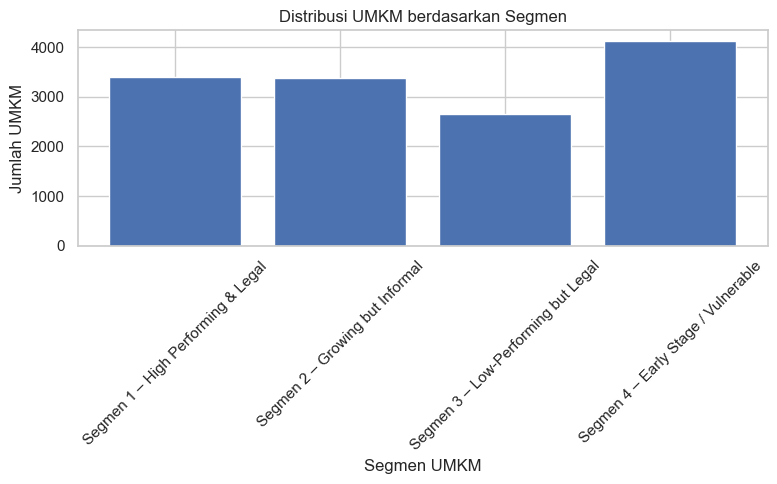

In [97]:
plt.bar(segment_counts.index, segment_counts.values)

plt.xlabel("Segmen UMKM")
plt.ylabel("Jumlah UMKM")
plt.title("Distribusi UMKM berdasarkan Segmen")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
df.groupby("segmen_umkm")[["omset", "laba", "aset", "kapasitas_produksi"]].median()

,omset,laba,aset,kapasitas_produksi
segmen_umkm,,,,
Segmen 1 – High Performing & Legal,19320216.0,5429036.0,18916690.0,1172.0
Segmen 2 – Growing but Informal,16057654.0,3776003.0,17026821.0,1037.0
Segmen 3 – Low-Performing but Legal,7994374.0,2214935.5,7953638.5,435.5
Segmen 4 – Early Stage / Vulnerable,8029214.0,1620853.0,7610591.0,424.5


### Insight per Segmen

**Segmen 1 - High Performing & Legal**

Segmen ini merupakan kelompok UMKM paling matang dan stabil. Mereka telah memenuhi aspek administratif dan menunjukkan performa usaha yang kuat.

Karakteristik:
- Omset di atas median
- Sudah terdaftar secara legal
- Skala usaha relatif lebih besar dari segmen lainnya.

Implikasi Bisnis:

Prioritas pembiayaan, perluasan pasar, dan digitalisasi lanjutan.

**Segmen 2 - Growing but Informal**

Kelompok ini memiliki performa ekonomi yang baik namun masih berada di sektor informal. Ini menunjukkan adanya potensi pajak, pembiayaan, dan akses program pemerintah yang belum optimal.

Karakteristik:
- Omset di atas median
- Belum terdaftar secara legal

Implikasi Bisnis:

Percepatan proses legalisasi dan integrasi UMKM ke ekosistem formal.

**Segmen 3 - Low-Performing but Legal**

UMKM pada segmen ini telah memenuhi aspek administratif, namun menghadapi tantangan dari sisi performa usaha. Diperlukan pendampingan operasional, seperti efisiensi biaya, pemasaran, atau pengelolaan keuangan.

Karakteristik:
- Omset di bawah median
- Sudah terdaftar secara legal

Implikasi Bisnis:

Pendampingan produktivitas, pelatihan manajemen dan pemasaran, serta optimasi biaya dan efisiensi operasional.

**Segmen 4 - Early Stage/Vulnerable UMKM**

Segmen ini merupakan kelompok paling rentan, dan yang paling banyak jumlahnya. Skala usaha masih kecil dan belum memiliki legalitas formal.

Karakteristik:
- Omset di bawah median
- Belum terdaftar secara legal

Implikasi Bisnis:

Program inkubasi bisnis, pelatihan dasar kewirausahaan, serta mentoring bisnis.

## 7. Business Implications & Recommendations

Berdasarkan hasil analisis dan segmentasi UMKM, terdapat beberapa implikasi strategis utama sebagai berikut:

- Kebijakan berbasis segmentasi diperlukan untuk meningkatkan efektivitas intervensi. UMKM memiliki karakteristik yang heterogen, sehingga program pembinaan, pembiayaan, dan pengembangan perlu disesuaikan dengan tingkat legalitas dan skala omset masing-masing segmen.

- Legalisasi dan integrasi UMKM informal berperforma tinggi merupakan peluang strategis. Percepatan formalitas usaha dapat memperluas akses pembiayaan, meningkatkan kontribusi ekonomi formal, serta memperkuat ekosistem UMKM secara keseluruhan.

- Penguatan kapasitas operasional dan produktivitas tenaga kerja menjadi prioritas utama. Temuan bahwa tenaga kerja memiliki korelasi tertinggi dengan omset menunjukkan bahwa peningkatan kompetensi, efisiensi, dan manajemen usaha berpotensi memberikan dampak lebih signifikan dibanding sekadar penambahan aset.

- Pendekatan bertahap diperlukan bagi UMKM tahap awal. Program inkubasi, pelatihan dasar kewirausahaan, dan mentoring bisnis menjadi fondasi sebelum diarahkan ke ekspansi dan akses pembiayaan formal.

## 8. Conclusion

Analisis ini memberikan gambaran mengenai karakteristik UMKM serta faktor-faktor yang berkaitan dengan performa usaha. Hasil menunjukkan bahwa tenaga kerja memiliki hubungan yang lebih kuat terhadap omset dibandingkan aset, sehingga kapasitas operasional dan produktivitas menjadi faktor yang penting dalam mendorong kinerja usaha.

Melalui segmentasi berbasis omset dan legalitas, UMKM terbagi ke dalam kelompok dengan kebutuhan intervensi yang berbeda, menegaskan pentingnya pendekatan kebijakan yang lebih terarah dan berbasis data. Temuan dari EDA ini dapat menjadi dasar untuk analisis lanjutan, seperti pemodelan prediktif maupun evaluasi kebijakan pengembangan UMKM.

## 9. Limitations & Suggestions

**Limitations:**
- Analisis bersifat eksploratif (EDA) sehingga tidak menguji hubungan kausal antar variabel.

- Variabel yang digunakan terbatas pada data yang tersedia dan belum mencakup faktor eksternal seperti lokasi, kondisi pasar, maupun tingkat persaingan.

- Segmentasi dilakukan secara rule-based berbasis median, sehingga belum mempertimbangkan pendekatan statistik atau machine learning yang lebih dinamis.

**Suggestions:**
- Penelitian selanjutnya dapat menggunakan metode inferensial atau pemodelan prediktif untuk menguji faktor-faktor yang secara signifikan memengaruhi performa UMKM.

- Penambahan variabel eksternal (geografis, akses pasar, digitalisasi, dll.) dapat meningkatkan kedalaman analisis.

- Penggunaan teknik clustering atau segmentation berbasis data-driven dapat memberikan insight yang lebih granular.

## 10. Appendix

- ***Data Dictionary***
- Data Cleaning & Transformation Log
- Segmentation Rules
- Additional EDA Tables & Charts
- Assumptions & Analytical Decisions
- Notebook / Code Reference